# Logistic Regression
<hr>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix)

### Loading Data

In [2]:
heart_data = pd.read_csv('../heart_disease.csv')

### Statistical Summary

In [3]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


### Preprocessing

In [4]:
# Drop 'num' column and Separate features(X) and target(y)
X = heart_data.drop(columns=['target_binary', 'num'])
y = heart_data['target_binary']

print("Feature shape: ", X.shape)
print("Target shape: ", y.shape)
print("Feature Columns: ", list(X.columns))

# Train-Test split, (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42,stratify=y)


print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0]) 

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler (only done once, in this notebook)
joblib.dump(scaler, 'scaler.pkl')

# Save test data (only done once, in this notebook)
test_data = pd.DataFrame(X_test_scaled, columns=X.columns)
test_data['target_binary'] = y_test.values
test_data.to_csv('../test_data.csv', index=False)

print("Shape of X:", X.shape)
print("Train size:", X_train_scaled.shape[0])
print("Test size:", X_test_scaled.shape[0])
print("scaler.pkl saved!")
print("test_data.csv saved!")

Feature shape:  (1024, 13)
Target shape:  (1024,)
Feature Columns:  ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Train size: 819
Test size: 205
Shape of X: (1024, 13)
Train size: 819
Test size: 205
scaler.pkl saved!
test_data.csv saved!


### Training Logistic Model

In [5]:
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Predicting using the trained model

In [6]:
logistic_predicted_y = logistic_regression_model.predict(X_test_scaled)
logistic_probability_y = logistic_regression_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression training done")

Logistic Regression training done


### Performance Metrics

In [7]:
logistic_accuracy  = accuracy_score(y_test, logistic_predicted_y)
logistic_auc       = roc_auc_score(y_test, logistic_probability_y)
logistic_precision = precision_score(y_test, logistic_predicted_y)
logistic_recall    = recall_score(y_test, logistic_predicted_y)
logistic_f1        = f1_score(y_test, logistic_predicted_y)
logistic_mcc       = matthews_corrcoef(y_test, logistic_predicted_y)

print("Logistic Regression Metrics")
print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"AUC       : {logistic_auc:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")
print(f"MCC       : {logistic_mcc:.4f}")

Logistic Regression Metrics
Accuracy  : 0.8585
AUC       : 0.9251
Precision : 0.8571
Recall    : 0.8298
F1 Score  : 0.8432
MCC       : 0.7147


### Confusion Matrix

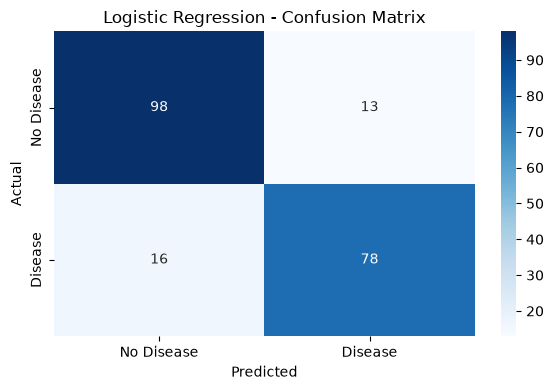

In [8]:
cm = confusion_matrix(y_test, logistic_predicted_y)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [9]:
joblib.dump(logistic_regression_model, 'logistic_regression.pkl')
print("logistic_regression.pkl saved!")

logistic_regression.pkl saved!
